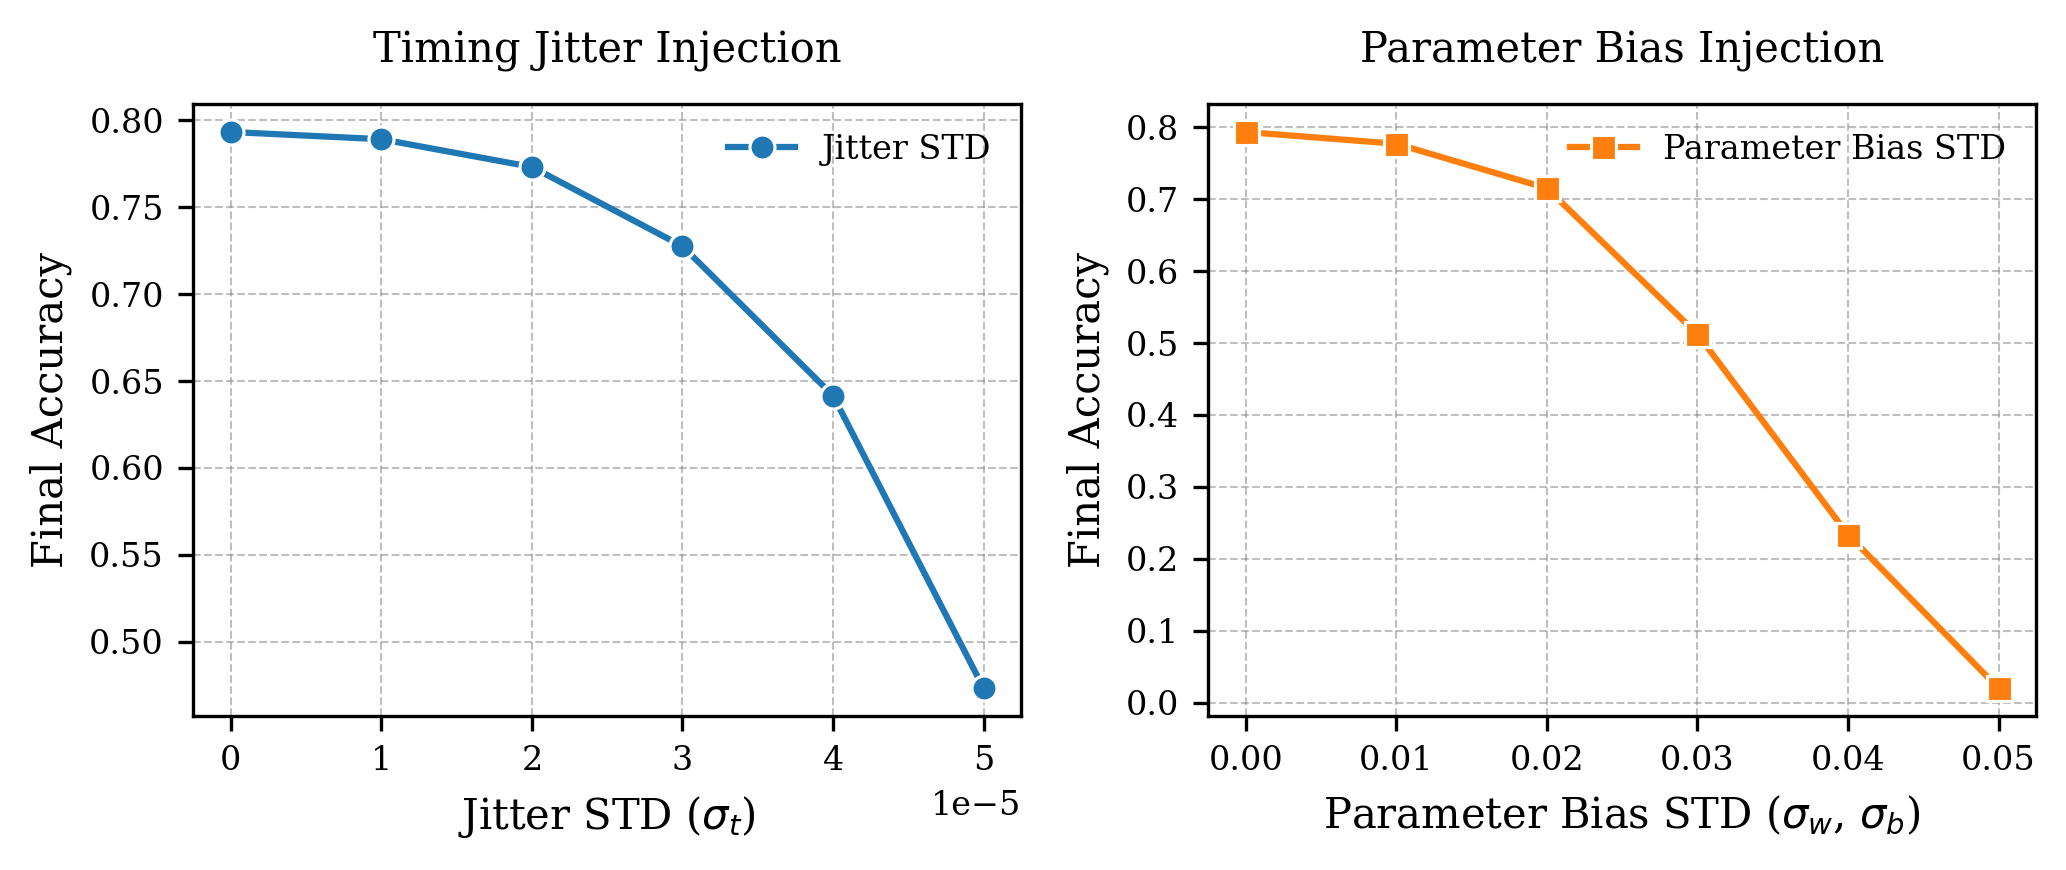

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 불러오기
file_path = "./wandb_export_2026-05-04T07_34_19.010+09_00.csv"  # 실제 파일 경로로 변경
df = pd.read_csv(file_path)

Y_COL = "Final Accuracy"      
GROUP_COL = "Name"            

# 2. 그룹 분류 함수
def categorize_method(run_name):
    run_name = str(run_name).lower()
    if 'weight-bias-std' in run_name:
        return 'Weight-Bias STD'
    elif 'std' in run_name:
        return 'Standard STD'
    else:
        return 'Other'

df['Method'] = df[GROUP_COL].apply(categorize_method)

# ---------------------------------------------------------
# 💡 핵심 포인트: 데이터를 그룹별로 분리하고 결측치 제거
# ---------------------------------------------------------
df_std = df[df['Method'] == 'Standard STD'].copy()
df_wb = df[df['Method'] == 'Weight-Bias STD'].copy()

# 각 그래프에 필요한 x축 데이터가 없는 행(NaN)은 안전하게 제외
df_std = df_std.dropna(subset=['noise_std', Y_COL])
df_wb = df_wb.dropna(subset=['bias_noise_std', Y_COL])

# 3. NeurIPS 논문용 Matplotlib 스타일 설정
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.grid": True
})

# 4. 그래프 그리기 (1행 2열 구조, 가로로 넓게 배치)
fig, axes = plt.subplots(1, 2, figsize=(7, 3))

# --- 첫 번째 그래프: Standard STD ---
sns.lineplot(
    data=df_std,
    x='noise_std',
    y=Y_COL,
    color='#1f77b4',             # 기본 파란색
    marker='o',
    linewidth=1.5,
    markersize=6,
    ax=axes[0],
    errorbar=('ci', 95),
    label='Jitter STD'
)
axes[0].set_xlabel(r'Jitter STD ($\sigma_t$)')
axes[0].set_ylabel('Final Accuracy')
axes[0].set_title('Timing Jitter Injection', pad=10)

# --- 두 번째 그래프: Parameter Bias STD ---
sns.lineplot(
    data=df_wb,
    x='bias_noise_std',
    y=Y_COL,
    color='#ff7f0e',             # 기본 주황색
    marker='s',
    linewidth=1.5,
    markersize=6,
    ax=axes[1],
    errorbar=('ci', 95),
    label='Parameter Bias STD'
)
axes[1].set_xlabel(r'Parameter Bias STD ($\sigma_w$, $\sigma_b$)')
axes[1].set_ylabel('Final Accuracy')
axes[1].set_title('Parameter Bias Injection', pad=10)

# 5. 그리드 및 범례 등 공통 스타일 조정
for ax in axes:
    ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.legend(frameon=False)

# 6. PDF로 저장
plt.tight_layout()
plt.savefig('separated_std_performance.pdf', format='pdf', bbox_inches='tight')
plt.show()